In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [39]:
df = pd.read_csv('economic_index.csv')

In [40]:
df.drop(df.columns[0], axis=1, inplace=True)
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [41]:
df.drop(columns=['year','month'],inplace=True)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   interest_rate      24 non-null     float64
 1   unemployment_rate  24 non-null     float64
 2   index_price        24 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 708.0 bytes


In [43]:
df.describe()

,interest_rate,unemployment_rate,index_price
count,24.000000,24.00000,24.000000
mean,2.072917,5.77500,1070.083333
std,0.349527,0.33002,210.735341
min,1.750000,5.30000,704.000000
25%,1.750000,5.50000,928.250000
50%,2.000000,5.85000,1061.000000
75%,2.500000,6.10000,1239.000000
max,2.750000,6.20000,1464.000000


In [44]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

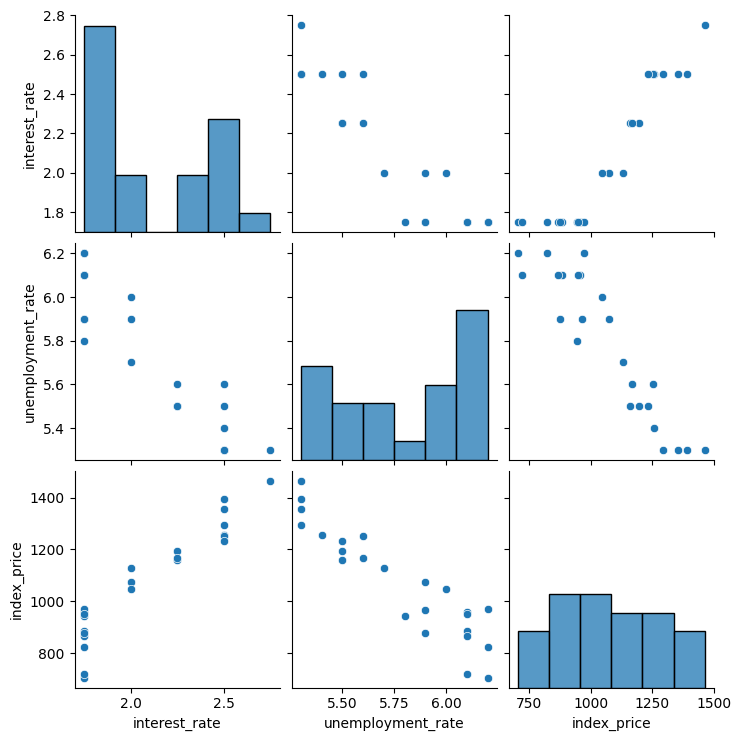

In [45]:
import seaborn as sns
sns.pairplot(df)

<Axes: >

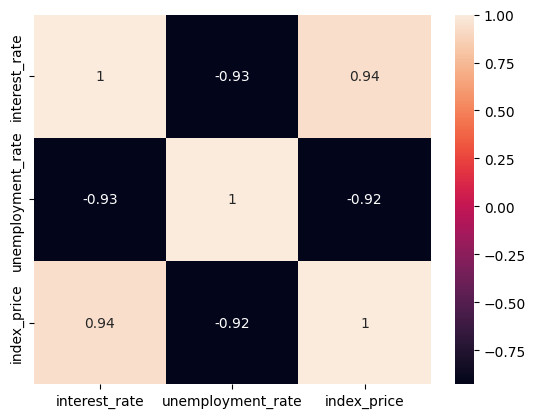

In [46]:
sns.heatmap(df.corr(),annot=True)

In [47]:
X = df.iloc[:,:-1]

In [48]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [49]:
y = df.iloc[:, -1]


In [50]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


`regplot` is a quick way to **visualize the relationship between two variables** and **overlay a fitted regression line**.

You use it to:
- See if the relationship looks roughly linear.
- Spot outliers or weird patterns.
- Get a quick sense of direction (positive/negative) and strength.
- Check whether a linear model is reasonable before training.


<Axes: xlabel='interest_rate', ylabel='index_price'>

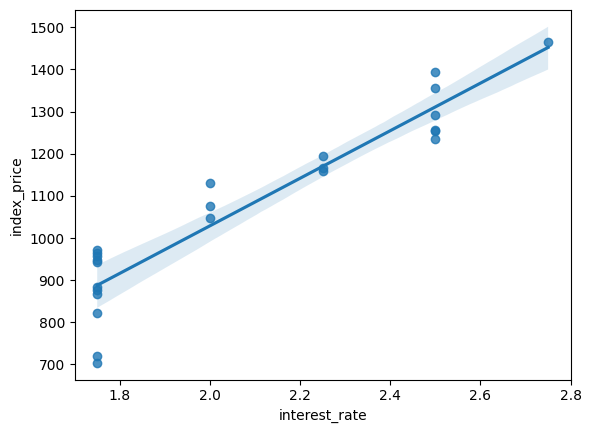

In [54]:
import seaborn as sns
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

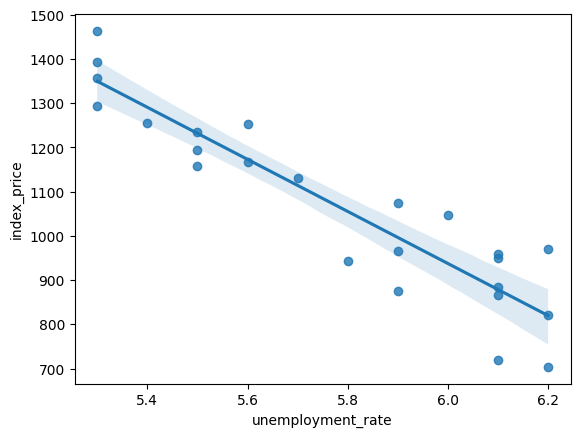

In [55]:
sns.regplot(x=df['unemployment_rate'], y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='interest_rate'>

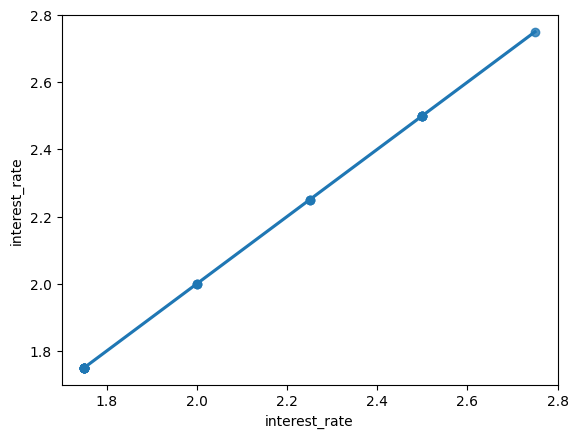

In [56]:
sns.regplot(x=df['interest_rate'], y=df['interest_rate'])

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [60]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [62]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [63]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
print("Coefficient or slope",regression.coef_)
print("Intercept: ",regression.intercept_)

Coefficient or slope [  88.27275507 -116.25716066]
Intercept:  1053.4444444444443


In [67]:
from sklearn.model_selection import cross_val_score

Cross validation is a technique to evaluate how well a machine learning model will generalize to unseen data. It involves splitting the dataset into multiple subsets (folds), training the model on some folds, and testing it on the remaining fold. This process is repeated several times, with each fold serving as the test set once. The results are averaged to provide a more reliable estimate of the model's performance, helping to prevent overfitting and ensure that the model can perform well on new data.

In [ ]:
## Cross validation

validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error', cv=3)

In [70]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [71]:
np.mean(validation_score)

np.float64(-5914.8281801623925)

In [64]:
y_pred = regression.predict(X_test)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mse)
print("Mean Square Error: ",mse)
print("Mean Absolute Error: ",mae)
print("RMSE: ",rmse)

Mean Square Error:  8108.567426306604
Mean Absolute Error:  73.80444932337097
RMSE:  90.04758423359621


In [73]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print("R2 value: ",r2)

R2 value:  0.7591371539010257


Assumptions

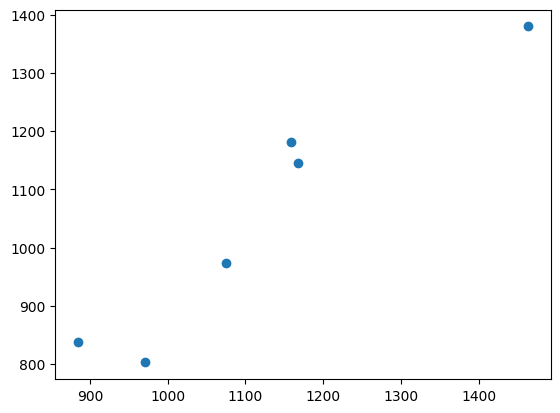

In [74]:
plt.scatter(y_test,y_pred)

In [75]:
residuals = y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


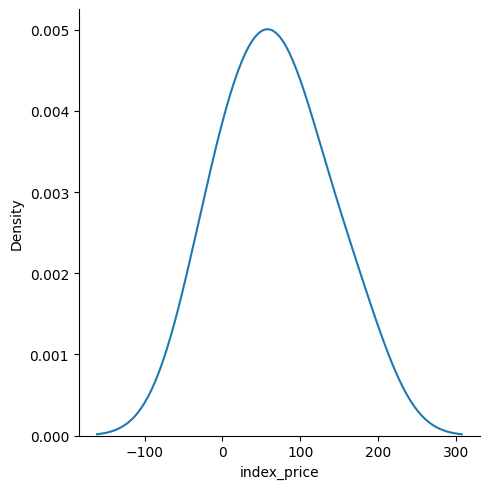

In [76]:
sns.displot(residuals,kind='kde')

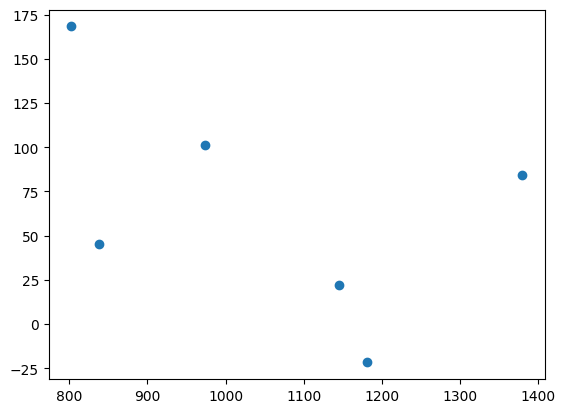

In [77]:
plt.scatter(y_pred,residuals)

In [78]:
### OLS Linear Regression
import statsmodels.api as sm 
model = sm.OLS(y_train,X_train).fit()
prediction = model.predict(X_test)

In [79]:
print(prediction)

[ 127.30223686 -250.70164745  326.390126   -214.91844842  -79.59130481
   91.51903783]


In [80]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Tue, 12 May 2026   Prob (F-statistic):                       0.754
Time:                        12:03:04   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------